# MNIST를 활용한 숫자 인식

In [1]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache direc

In [2]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

* 모든 설치가 끝나면 한글 폰트를 바르게 출력하기 위해 **[런타임]** -> **[런타임 다시시작]**을 클릭한 다음, 아래 셀부터 코드를 실행해 주십시오.

In [3]:
# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

In [4]:
# 파이토치 관련 라이브러리

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torchviz import make_dot

In [5]:
# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

## 8.4 활성화 함수와 ReLU 함수

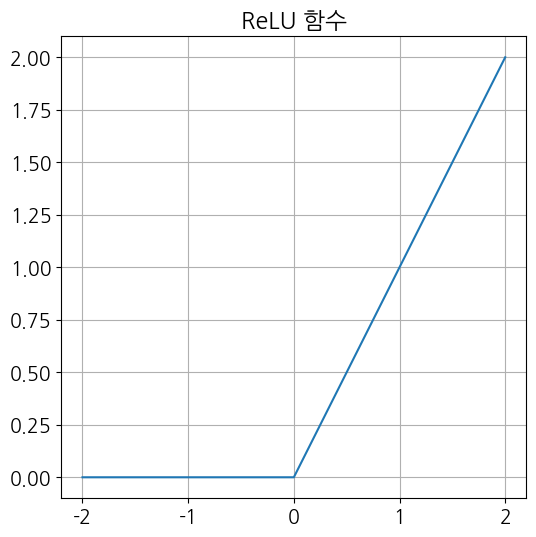

In [6]:
# ReLU 함수의 그래프

relu = nn.ReLU() # ReLU 함수 인스턴스 생성
x_np = np.arange(-2.0, 2.1, 0.25) # -2.0부터 2.0까지 0.25 간격으로 숫자 생성
x = torch.tensor(x_np).float() # 넘파이 배열을 파이토치 텐서로 변환
y = relu(x) # x 텐서에 ReLU 함수 적용

# 그래프 출력
plt.plot(x.data, y.data)
plt.title('ReLU 함수')
plt.grid(True)
plt.show()

## 8.5 GPU 사용하기

### GPU 디바이스 확인

In [7]:
# 디바이스 할당
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [8]:
# 텐서 변수 x, y
x_np = np.arange(-2.0, 2.1, 0.25)
y_np = np.arange(-1.0, 3.1, 0.25)
x = torch.tensor(x_np).float()
y = torch.tensor(y_np).float()

# x와 y 사이의 연산
z = x * y
print(z)
print('z의 디바이스:', z.device)

tensor([ 2.0000,  1.3125,  0.7500,  0.3125, -0.0000, -0.1875, -0.2500, -0.1875,
         0.0000,  0.3125,  0.7500,  1.3125,  2.0000,  2.8125,  3.7500,  4.8125,
         6.0000])
z의 디바이스: cpu


In [9]:
# 변수 x를 GPU로 보냄
x = x.to(device)

# 변수 x와 y의 디바이스 속성 확인
print('x: ', x.device)
print('y: ', y.device)

x:  cuda:0
y:  cpu


In [10]:
# GPU상의 변수와 CPU상의 변수 간 연산 결과
try:
    # 이 상태에서 x와 y의 연산을 수행하면
    z = x * y
except RuntimeError as e:
    print(e)

Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!


In [11]:
# y도 GPU로 보냄
y = y.to(device)

# 연산이 가능해짐
z = x * y
print(z)

tensor([ 2.0000,  1.3125,  0.7500,  0.3125, -0.0000, -0.1875, -0.2500, -0.1875,
         0.0000,  0.3125,  0.7500,  1.3125,  2.0000,  2.8125,  3.7500,  4.8125,
         6.0000], device='cuda:0')


## 8.8 데이터 준비 1  (Dataset을 활용해 불러오기)

In [12]:
%pwd
# present working directory

'/content'

In [13]:
# 라이브러리 임포트
import torchvision.datasets as datasets

# 다운로드받을 디렉터리명
data_root = './data'

train_set0 = datasets.MNIST(
    # 원본 데이터를 다운로드받을 디렉터리 지정
    root = data_root,
    # 훈련 데이터인지 또는 검증 데이터인지
    train = True,
    # 원본 데이터가 없는 경우, 다운로드를 실행하는지 여부
    download = True)

In [14]:
# 다운로드한 파일 확인

!ls -lR ./data/MNIST

# 출력 내용 >> -rw-r--r-- : 데이터 권한 의미

./data/MNIST:
total 4
drwxr-xr-x 2 root root 4096 May 28 04:44 raw

./data/MNIST/raw:
total 65008
-rw-r--r-- 1 root root  7840016 May 28 04:44 t10k-images-idx3-ubyte
-rw-r--r-- 1 root root  1648877 May 28 04:44 t10k-images-idx3-ubyte.gz
-rw-r--r-- 1 root root    10008 May 28 04:44 t10k-labels-idx1-ubyte
-rw-r--r-- 1 root root     4542 May 28 04:44 t10k-labels-idx1-ubyte.gz
-rw-r--r-- 1 root root 47040016 May 28 04:43 train-images-idx3-ubyte
-rw-r--r-- 1 root root  9912422 May 28 04:43 train-images-idx3-ubyte.gz
-rw-r--r-- 1 root root    60008 May 28 04:43 train-labels-idx1-ubyte
-rw-r--r-- 1 root root    28881 May 28 04:43 train-labels-idx1-ubyte.gz


In [15]:
# 데이터 건수 확인
print('데이터 건수: ', len(train_set0))

# 첫번째 요소 가져오기
image, label = train_set0[0]

# 데이터 타입 확인
print('입력 데이터 타입 : ', type(image))
print('정답 데이터 타입 : ', type(label))

데이터 건수:  60000
입력 데이터 타입 :  <class 'PIL.Image.Image'>
정답 데이터 타입 :  <class 'int'>


In [16]:
image

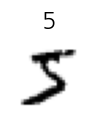

In [17]:
# 입력 데이터를 이미지로 출력

plt.figure(figsize=(1,1))
plt.title(f'{label}')
plt.imshow(image, cmap='gray_r')    # cmap = 'gray_r' 색 반전
plt.axis('off')
plt.show()

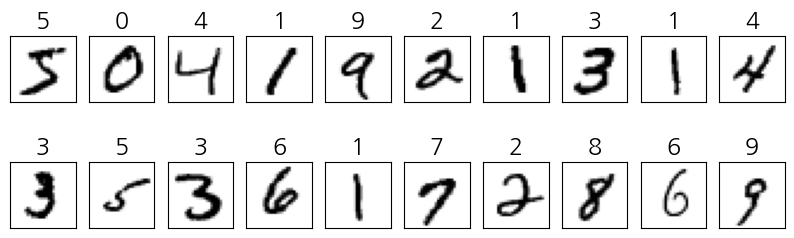

In [18]:
# 정답 데이터와 함께 처음 20개 데이터를 이미지로 출력

plt.figure(figsize=(10, 3))
for i in range(20):
    ax = plt.subplot(2, 10, i + 1)

    # image와 label 취득
    image, label = train_set0[i]

    # 이미지 출력
    plt.imshow(image, cmap='gray_r')
    ax.set_title(f'{label}')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

## 8.9 데이터 준비 2  (Transforms를 활용한 데이터 전처리)

### 스텝 1. ToTensor 사용하기

In [19]:
# 라이브러리 임포트
import torchvision.transforms as transforms

transform1 = transforms.Compose([
    # 데이터를 텐서로 변환
    transforms.ToTensor(),
])

train_set1 = datasets.MNIST(
    root=data_root,  train=True,  download=True,
    transform = transform1)

In [20]:
# 변환 결과 확인

image, label = train_set1[0]
print('입력 데이터 타입 : ', type(image))
print('입력 데이터 shape : ', image.shape)
print('최솟값 : ', image.data.min())
print('최댓값 : ', image.data.max())

입력 데이터 타입 :  <class 'torch.Tensor'>
입력 데이터 shape :  torch.Size([1, 28, 28])
최솟값 :  tensor(0.)
최댓값 :  tensor(1.)


### 스텝 2. Normalize 사용하기

In [21]:
transform2 = transforms.Compose([
    # 데이터를 텐서로 변환
    transforms.ToTensor(),

    # 데이터 정규화
    transforms.Normalize(0.5,  0.5),
])

train_set2 = datasets.MNIST(
    root = data_root,  train = True,  download = True,
    transform = transform2)

In [22]:
# 변환 결과 확인

image, label = train_set2[0]
print('shape : ', image.shape)
print('최솟값 : ', image.data.min())
print('최댓값 : ', image.data.max())

shape :  torch.Size([1, 28, 28])
최솟값 :  tensor(-1.)
최댓값 :  tensor(1.)


### 스텝 3. Lambda 클래스를 사용해 1차원으로 텐서 변환하기

In [23]:
transform3 = transforms.Compose([
    # 데이터를 텐서로 변환
    transforms.ToTensor(),

    # 데이터 정규화
    transforms.Normalize(0.5, 0.5),

    # 현재 텐서를 1계 텐서로 변환
    transforms.Lambda(lambda x: x.view(-1)),
])

train_set3 = datasets.MNIST(
    root = data_root,  train = True,
    download=True, transform = transform3)

In [24]:
# # 실습
# transform3 = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize(0.5, 0.5),
#     transforms.Lambda(lambda x: x.view(-1)),
# ])

# train_set3 = datasets.MNIST(
#     root = data_root, train = True,
#     download = True, transform = transform3
# )

In [25]:
# 변환 결과 확인

image, label = train_set3[0]
print('shape : ', image.shape)
print('최솟값 : ', image.data.min())
print('최댓값 : ', image.data.max())

shape :  torch.Size([784])
최솟값 :  tensor(-1.)
최댓값 :  tensor(1.)


### 최종 구현 형태

In [26]:
# 데이터 변환용 함수 Transforms
# (1) Image를 텐서화
# (2) [0, 1] 범위의 값을 [-1, 1] 범위로 조정
# (3) 데이터의 shape을 [1, 28, 28] 에서 [784] 로 변환
# train data >> 이미지 보강 등 내용 추가

transform = transforms.Compose([
    # (1) 데이터를 텐서로 변환
    transforms.ToTensor(),

    # (2) 데이터 정규화
    transforms.Normalize(0.5, 0.5),

    # (3) 1계 텐서로 변환
    transforms.Lambda(lambda x: x.view(-1)),
])

In [27]:
# 데이터 입수를 위한 Dataset 함수

# 훈련용 데이터셋 정의
train_set = datasets.MNIST(
    root = data_root, train = True,
    download = True, transform = transform)

# 검증용 데이터셋 정의
test_set = datasets.MNIST(
    root = data_root, train = False,
    download = True, transform = transform)

## 8.10 데이터 준비 3  (데이터로더를 활용한 미니 배치 데이터 생성)

In [28]:
# 라이브러리 임포트
from torch.utils.data import DataLoader

# 미니 배치 사이즈 지정
batch_size = 500

# 훈련용 데이터로더
# 훈련용이므로, 셔플을 적용함
train_loader = DataLoader(
    train_set, batch_size = batch_size,
    shuffle = True)

# 검증용 데이터로더
# 검증시에는 셔플을 필요로하지 않음
test_loader = DataLoader(
    test_set,  batch_size = batch_size,
    shuffle = False)

In [29]:
# 몇 개의 그룹으로 데이터를 가져올 수 있는가
print('총 미니 배치 개수:', len(train_loader)) # 60000 / 500 = 120

# 데이터로더로부터 가장 처음 한 세트를 가져옴
for images, labels in train_loader:
    break

print('images의 shape:', images.shape)
print('labels의 shape:', labels.shape)

총 미니 배치 개수: 120
images의 shape: torch.Size([500, 784])
labels의 shape: torch.Size([500])


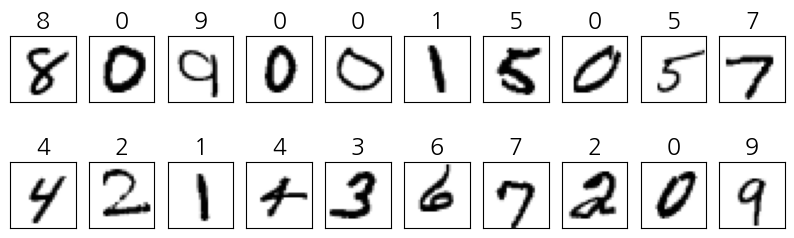

In [30]:
# 이미지 출력
plt.figure(figsize=(10, 3))
for i in range(20):
    ax = plt.subplot(2, 10, i + 1)

    # 넘파이로 배열로 변환
    image = images[i].numpy()
    label = labels[i]

    # 이미지의 범위를 [0, 1] 로 되돌림
    # 현재 범위는 -1과 1 사이
    image2 = (image + 1)/ 2

    # 이미지 출력
    plt.imshow(image2.reshape(28, 28),cmap='gray_r')
    ax.set_title(f'{label}')
    ax.get_xaxis().set_visible(False)   # 축 안보이게 설정
    ax.get_yaxis().set_visible(False)
plt.show()

모두 60,000건의 훈련 데이터가 120개의 그룹으로 분할되었음을 알 수 있다.
이번에는 테스트용으로 셔플을 하지 않은 데이터를 정의했지만, 훈련 데이터는 한번 취득할 때 마다 셔플이 이뤄진다.

## 8.11 모델 정의

In [31]:
image.shape

(784,)

In [32]:
image.shape[0]

784

In [33]:
labels
labels.numpy()

array([8, 0, 9, 0, 0, 1, 5, 0, 5, 7, 4, 2, 1, 4, 3, 6, 7, 2, 0, 9, 0, 8,
       3, 1, 5, 5, 8, 7, 6, 0, 4, 6, 8, 6, 4, 0, 4, 4, 2, 2, 0, 1, 4, 9,
       1, 8, 3, 6, 0, 4, 6, 7, 0, 4, 1, 0, 7, 5, 5, 5, 1, 9, 7, 0, 0, 4,
       3, 2, 2, 7, 2, 2, 0, 5, 9, 1, 1, 2, 9, 1, 6, 3, 0, 3, 7, 1, 5, 2,
       8, 2, 8, 9, 6, 1, 1, 8, 7, 1, 0, 6, 3, 3, 4, 1, 0, 1, 3, 1, 7, 3,
       8, 9, 7, 4, 7, 2, 7, 4, 9, 6, 5, 3, 3, 2, 8, 0, 6, 3, 4, 3, 5, 4,
       8, 6, 1, 1, 3, 0, 6, 3, 9, 4, 8, 5, 7, 5, 4, 4, 9, 8, 2, 0, 5, 6,
       9, 5, 1, 4, 3, 4, 4, 1, 7, 7, 7, 0, 0, 9, 5, 2, 3, 0, 8, 0, 5, 9,
       2, 7, 2, 3, 7, 9, 9, 0, 0, 6, 3, 8, 8, 5, 1, 7, 0, 3, 1, 7, 3, 6,
       9, 5, 0, 2, 4, 5, 6, 2, 4, 8, 8, 1, 7, 4, 7, 4, 5, 9, 0, 4, 9, 9,
       1, 8, 9, 1, 8, 3, 5, 6, 4, 9, 1, 7, 2, 9, 1, 6, 7, 9, 1, 7, 2, 9,
       1, 1, 1, 1, 8, 4, 4, 7, 8, 4, 2, 8, 8, 8, 5, 5, 1, 8, 8, 6, 4, 3,
       2, 9, 1, 6, 3, 6, 8, 2, 4, 8, 3, 2, 5, 0, 9, 9, 3, 8, 5, 6, 3, 0,
       3, 4, 1, 5, 6, 1, 5, 2, 6, 7, 3, 1, 8, 7, 4,

In [34]:
set(list(labels.data.numpy()))

{np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9)}

In [35]:
len(set(list(labels.data.numpy())))

10

In [36]:
# 입력 차원수
n_input = image.shape[0]

# 출력 차원수
# 분류 클래스 수는 10
n_output = len(set(list(labels.data.numpy())))

# 은닉층의 노드 수
n_hidden = 128

# 결과 확인
print(f'n_input: {n_input}  n_hidden: {n_hidden} n_output: {n_output}')

n_input: 784  n_hidden: 128 n_output: 10


In [37]:
# 모델 정의
# 784입력 10출력 1은닉층의 신경망 모델

class Net(nn.Module):
    def __init__(self, n_input, n_output, n_hidden):
        super().__init__()

        # 은닉층 정의(은닉층 노드 수 : n_hidden)
        self.l1 = nn.Linear(n_input, n_hidden)

        # 출력층 정의
        self.l2 = nn.Linear(n_hidden, n_output)

        # ReLU 함수 정의
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x1 = self.l1(x)
        x2 = self.relu(x1)
        x3 = self.l2(x2)
        return x3

In [38]:
# 난수 고정
torch.manual_seed(123)
torch.cuda.manual_seed(123)

# 모델 인스턴스 생성
net = Net(n_input, n_output, n_hidden)

# 모델을 GPU로 전송
net = net.to(device)

### 최적화 알고리즘과 손실 함수

In [39]:
# 학습률
lr = 0.01

# 최적화 알고리즘: 경사 하강법
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

# 손실 함수： 교차 엔트로피 함수
criterion = nn.CrossEntropyLoss()

### 모델 확인

In [40]:
# 모델 내부 파라미터 확인
# l1.weight, l1.bias, l2.weight, l2.bias를 확인할 수 있음

for parameter in net.named_parameters():
    print(parameter)

('l1.weight', Parameter containing:
tensor([[-0.0146,  0.0012, -0.0177,  ...,  0.0277,  0.0200,  0.0315],
        [ 0.0184, -0.0322,  0.0175,  ...,  0.0089, -0.0028, -0.0033],
        [ 0.0092,  0.0261,  0.0075,  ...,  0.0061,  0.0267, -0.0258],
        ...,
        [ 0.0235, -0.0026, -0.0129,  ...,  0.0322, -0.0059, -0.0169],
        [-0.0328, -0.0258,  0.0124,  ..., -0.0049,  0.0006,  0.0334],
        [ 0.0187, -0.0076, -0.0202,  ...,  0.0325, -0.0159, -0.0240]],
       device='cuda:0', requires_grad=True))
('l1.bias', Parameter containing:
tensor([ 0.0325, -0.0298,  0.0013,  0.0199,  0.0268, -0.0248, -0.0172, -0.0355,
         0.0122, -0.0048,  0.0214,  0.0202, -0.0243,  0.0015, -0.0276,  0.0296,
         0.0341, -0.0228,  0.0230,  0.0347, -0.0091, -0.0346,  0.0206, -0.0060,
         0.0329,  0.0047,  0.0180,  0.0101,  0.0177, -0.0309,  0.0228, -0.0224,
         0.0321,  0.0179,  0.0321,  0.0184,  0.0219, -0.0089,  0.0310, -0.0039,
        -0.0074, -0.0317,  0.0192, -0.0021,  0.0190

In [41]:
# 모델 개요 표시 1

print(net)

Net(
  (l1): Linear(in_features=784, out_features=128, bias=True)
  (l2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU(inplace=True)
)


In [42]:
# 모델 개요 표시 2

summary(net, (784,))

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [10]                      --
├─Linear: 1-1                            [128]                     100,480
├─ReLU: 1-2                              [128]                     --
├─Linear: 1-3                            [10]                      1,290
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 12.87
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.41
Estimated Total Size (MB): 0.41

## 8.12 경사 하강법

### 예측 계산

In [53]:
# 데이터로더에서 가장 처음 항목을 취득
for images, labels in train_loader:
    break

In [54]:
# 데이터로더에서 취득한 데이터를 GPU로 보냄
inputs = images.to(device)
labels = labels.to(device)

In [55]:
# 예측 계산
outputs = net(inputs)

# 결과 확인
print(outputs)

tensor([[ 4.1213, -2.7511,  2.2933,  ...,  3.9382, -2.7925, -0.4936],
        [-4.3683, -4.2635, -3.9363,  ...,  0.7418,  0.2923,  4.7277],
        [-1.0645, -3.6703, -1.1014,  ...,  9.7277, -2.0778,  3.3947],
        ...,
        [-4.8219,  1.2468, -2.8940,  ...,  0.0869,  0.6012,  1.5455],
        [-4.7613,  3.5831,  1.6705,  ..., -2.5920,  1.5459, -1.0250],
        [-4.5918,  1.8474, -1.3068,  ...,  1.4079,  0.2888,  2.0990]],
       device='cuda:0', grad_fn=<AddmmBackward0>)


### 손실 함수

#### 손실 계산과 계산 그래프 시각화

0.42822176218032837


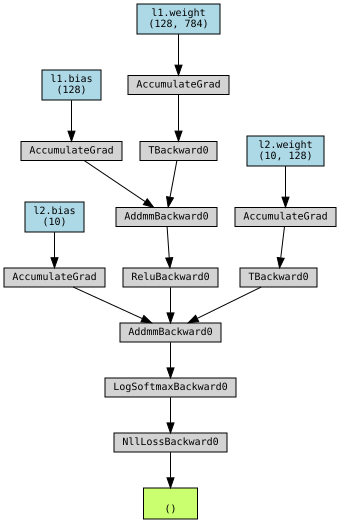

In [56]:
#  손실 계산
loss = criterion(outputs, labels)

# 손실값 가져오기
print(loss.item())

# 손실 계산 그래프 시각화
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

### 경사 계산

In [57]:
# 경사 계산 실행
loss.backward()

In [58]:
# 경사 계산 결과
w = net.to('cpu')
print(w.l1.weight.grad.numpy())
print(w.l1.bias.grad.numpy())
print(w.l2.weight.grad.numpy())
print(w.l2.bias.grad.numpy())

[[-0.0027 -0.0027 -0.0027 ... -0.0027 -0.0027 -0.0027]
 [-0.0027 -0.0027 -0.0027 ... -0.0027 -0.0027 -0.0027]
 [ 0.001   0.001   0.001  ...  0.001   0.001   0.001 ]
 ...
 [ 0.0018  0.0018  0.0018 ...  0.0018  0.0018  0.0018]
 [-0.0001 -0.0001 -0.0001 ... -0.0001 -0.0001 -0.0001]
 [-0.0008 -0.0008 -0.0008 ... -0.0008 -0.0008 -0.0008]]
[ 0.0027  0.0027 -0.001   0.0046  0.0006  0.005  -0.0006 -0.0006  0.002
 -0.003  -0.      0.0003 -0.     -0.0006 -0.001   0.0021 -0.0017  0.0039
  0.0014 -0.0026 -0.0002 -0.0011 -0.0017 -0.002   0.0011  0.0002  0.
  0.      0.0012  0.0056  0.0003  0.     -0.0036 -0.0003  0.0029 -0.0001
 -0.0026 -0.0012 -0.0034 -0.001  -0.004   0.0042 -0.0001 -0.0008 -0.0013
 -0.0009  0.0001  0.0023 -0.0026  0.0023  0.0001 -0.0006  0.0014 -0.0005
  0.0012  0.0021  0.0005  0.0077 -0.0003 -0.0019  0.0014  0.002  -0.0019
 -0.0013  0.     -0.0005 -0.0001  0.0003 -0.0029 -0.0009  0.0027 -0.0006
  0.0002  0.0013 -0.0023 -0.0004  0.0021  0.0031  0.0001  0.0002  0.001
 -0.0019 -0.0

### 파라미터 수정

In [59]:
# 경사 하강법 적용
optimizer.step()

In [60]:
# 파라미터 값 출력
print(net.l1.weight)
print(net.l1.bias)

Parameter containing:
tensor([[-0.0169, -0.0012, -0.0201,  ...,  0.0254,  0.0176,  0.0292],
        [ 0.0135, -0.0370,  0.0126,  ...,  0.0040, -0.0077, -0.0082],
        [ 0.0070,  0.0238,  0.0052,  ...,  0.0039,  0.0244, -0.0281],
        ...,
        [ 0.0220, -0.0041, -0.0144,  ...,  0.0308, -0.0074, -0.0184],
        [-0.0333, -0.0262,  0.0120,  ..., -0.0053,  0.0002,  0.0330],
        [ 0.0160, -0.0103, -0.0230,  ...,  0.0297, -0.0187, -0.0268]],
       requires_grad=True)
Parameter containing:
tensor([ 0.0348, -0.0249,  0.0035,  0.0228,  0.0335, -0.0196, -0.0131, -0.0328,
         0.0172, -0.0029,  0.0210,  0.0226, -0.0219,  0.0028, -0.0244,  0.0328,
         0.0341, -0.0194,  0.0249,  0.0357, -0.0077, -0.0336,  0.0224, -0.0062,
         0.0335,  0.0072,  0.0170,  0.0101,  0.0205, -0.0282,  0.0260, -0.0237,
         0.0356,  0.0191,  0.0355,  0.0184,  0.0234, -0.0083,  0.0328, -0.0021,
        -0.0052, -0.0319,  0.0182,  0.0031,  0.0230,  0.0067,  0.0350, -0.0004,
        -0.0096

### 반복 계산

In [61]:
# 난수 고정
torch.manual_seed(123)
torch.cuda.manual_seed(123)
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms = True

# 학습률
lr = 0.01

# 모델 초기화
net = Net(n_input, n_output, n_hidden).to(device)

# 손실 함수： 교차 엔트로피 함수
criterion = nn.CrossEntropyLoss()

# 최적화 함수: 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수
num_epochs = 100

# 평가 결과 기록
history = np.zeros((0,5))

In [62]:
# tqdm 라이브러리 임포트
from tqdm.notebook import tqdm
# 진행상황을 보여주는 바 -> 간혹 에러 발생할 수도 있음.

# 반복 계산 메인 루프
for epoch in range(num_epochs):
    train_acc, train_loss = 0, 0
    val_acc, val_loss = 0, 0
    n_train, n_test = 0, 0

    # 훈련 페이즈
    for inputs, labels in tqdm(train_loader):
        n_train += len(labels)

        # GPU로 전송
        inputs = inputs.to(device)
        labels = labels.to(device)

        # 경사 초기화
        optimizer.zero_grad()

        # 예측 계산
        outputs = net(inputs)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 경사 계산
        loss.backward()

        # 파라미터 수정
        optimizer.step()

        # 예측 라벨 산출
        predicted = torch.max(outputs, 1)[1]

        # 손실과 정확도 계산
        train_loss += loss.item()
        train_acc += (predicted == labels).sum().item()

    # 예측 페이즈
    # with torch.no_grad(): 있어야 해!!
    for inputs_test, labels_test in test_loader:
        n_test += len(labels_test)

        inputs_test = inputs_test.to(device)
        labels_test = labels_test.to(device)

        # 예측 계산
        outputs_test = net(inputs_test)

        # 손실 계산
        loss_test = criterion(outputs_test, labels_test)

        # 예측 라벨 산출
        predicted_test = torch.max(outputs_test, 1)[1]

        # 손실과 정확도 계산
        val_loss +=  loss_test.item()
        val_acc +=  (predicted_test == labels_test).sum().item()

    # 평가 결과 산출, 기록
    train_acc = train_acc / n_train
    val_acc = val_acc / n_test
    train_loss = train_loss * batch_size / n_train  # average train_loss
    val_loss = val_loss * batch_size / n_test
    print (f'Epoch [{epoch+1}/{num_epochs}], loss: {train_loss:.5f} acc: {train_acc:.5f} val_loss: {val_loss:.5f}, val_acc: {val_acc:.5f}')
    item = np.array([epoch+1 , train_loss, train_acc, val_loss, val_acc])
    history = np.vstack((history, item))

  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [1/100], loss: 1.82932 acc: 0.56958 val_loss: 1.32629, val_acc: 0.74660


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [2/100], loss: 1.03888 acc: 0.79537 val_loss: 0.79661, val_acc: 0.83180


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [3/100], loss: 0.70809 acc: 0.84110 val_loss: 0.60256, val_acc: 0.85850


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [4/100], loss: 0.57300 acc: 0.86057 val_loss: 0.51192, val_acc: 0.87140


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [5/100], loss: 0.50223 acc: 0.87102 val_loss: 0.45827, val_acc: 0.87920


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [6/100], loss: 0.45883 acc: 0.87878 val_loss: 0.42422, val_acc: 0.88650


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [7/100], loss: 0.42938 acc: 0.88327 val_loss: 0.40076, val_acc: 0.88970


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [8/100], loss: 0.40813 acc: 0.88743 val_loss: 0.38285, val_acc: 0.89370


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [9/100], loss: 0.39176 acc: 0.89065 val_loss: 0.36857, val_acc: 0.89680


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [10/100], loss: 0.37876 acc: 0.89313 val_loss: 0.35741, val_acc: 0.89930


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [11/100], loss: 0.36812 acc: 0.89592 val_loss: 0.34868, val_acc: 0.90160


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [12/100], loss: 0.35910 acc: 0.89783 val_loss: 0.34089, val_acc: 0.90220


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [13/100], loss: 0.35147 acc: 0.89977 val_loss: 0.33336, val_acc: 0.90490


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [14/100], loss: 0.34477 acc: 0.90135 val_loss: 0.32806, val_acc: 0.90570


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [15/100], loss: 0.33860 acc: 0.90310 val_loss: 0.32334, val_acc: 0.90710


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [16/100], loss: 0.33333 acc: 0.90412 val_loss: 0.31807, val_acc: 0.90790


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [17/100], loss: 0.32843 acc: 0.90520 val_loss: 0.31445, val_acc: 0.90930


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [18/100], loss: 0.32380 acc: 0.90700 val_loss: 0.31076, val_acc: 0.91090


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [19/100], loss: 0.31950 acc: 0.90807 val_loss: 0.30586, val_acc: 0.91190


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [20/100], loss: 0.31587 acc: 0.90905 val_loss: 0.30281, val_acc: 0.91240


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [21/100], loss: 0.31199 acc: 0.91032 val_loss: 0.29965, val_acc: 0.91520


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [22/100], loss: 0.30842 acc: 0.91098 val_loss: 0.29713, val_acc: 0.91430


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [23/100], loss: 0.30507 acc: 0.91195 val_loss: 0.29432, val_acc: 0.91570


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [24/100], loss: 0.30190 acc: 0.91320 val_loss: 0.29123, val_acc: 0.91770


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [25/100], loss: 0.29883 acc: 0.91403 val_loss: 0.28884, val_acc: 0.91700


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [26/100], loss: 0.29597 acc: 0.91492 val_loss: 0.28646, val_acc: 0.91820


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [27/100], loss: 0.29311 acc: 0.91662 val_loss: 0.28365, val_acc: 0.91950


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [28/100], loss: 0.29027 acc: 0.91698 val_loss: 0.28185, val_acc: 0.92000


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [29/100], loss: 0.28765 acc: 0.91798 val_loss: 0.28041, val_acc: 0.91950


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [30/100], loss: 0.28510 acc: 0.91858 val_loss: 0.27748, val_acc: 0.92110


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [31/100], loss: 0.28233 acc: 0.91958 val_loss: 0.27485, val_acc: 0.92180


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [32/100], loss: 0.27989 acc: 0.92040 val_loss: 0.27255, val_acc: 0.92120


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [33/100], loss: 0.27763 acc: 0.92067 val_loss: 0.27010, val_acc: 0.92210


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [34/100], loss: 0.27513 acc: 0.92102 val_loss: 0.26897, val_acc: 0.92410


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [35/100], loss: 0.27278 acc: 0.92242 val_loss: 0.26668, val_acc: 0.92430


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [36/100], loss: 0.27048 acc: 0.92280 val_loss: 0.26462, val_acc: 0.92360


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [37/100], loss: 0.26828 acc: 0.92358 val_loss: 0.26279, val_acc: 0.92440


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [38/100], loss: 0.26597 acc: 0.92403 val_loss: 0.26075, val_acc: 0.92550


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [39/100], loss: 0.26357 acc: 0.92455 val_loss: 0.25918, val_acc: 0.92580


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [40/100], loss: 0.26157 acc: 0.92565 val_loss: 0.25719, val_acc: 0.92660


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [41/100], loss: 0.25919 acc: 0.92603 val_loss: 0.25558, val_acc: 0.92630


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [42/100], loss: 0.25715 acc: 0.92695 val_loss: 0.25282, val_acc: 0.92720


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [43/100], loss: 0.25496 acc: 0.92765 val_loss: 0.25100, val_acc: 0.92940


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [44/100], loss: 0.25292 acc: 0.92775 val_loss: 0.24995, val_acc: 0.92800


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [45/100], loss: 0.25096 acc: 0.92845 val_loss: 0.24743, val_acc: 0.92930


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [46/100], loss: 0.24867 acc: 0.92937 val_loss: 0.24636, val_acc: 0.93070


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [47/100], loss: 0.24664 acc: 0.92965 val_loss: 0.24402, val_acc: 0.93100


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [48/100], loss: 0.24463 acc: 0.93042 val_loss: 0.24264, val_acc: 0.93060


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [49/100], loss: 0.24266 acc: 0.93060 val_loss: 0.24012, val_acc: 0.93220


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [50/100], loss: 0.24070 acc: 0.93147 val_loss: 0.23928, val_acc: 0.93250


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [51/100], loss: 0.23872 acc: 0.93212 val_loss: 0.23708, val_acc: 0.93300


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [52/100], loss: 0.23680 acc: 0.93225 val_loss: 0.23567, val_acc: 0.93290


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [53/100], loss: 0.23485 acc: 0.93345 val_loss: 0.23360, val_acc: 0.93310


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [54/100], loss: 0.23294 acc: 0.93442 val_loss: 0.23177, val_acc: 0.93430


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [55/100], loss: 0.23101 acc: 0.93478 val_loss: 0.22988, val_acc: 0.93460


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [56/100], loss: 0.22909 acc: 0.93517 val_loss: 0.22863, val_acc: 0.93460


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [57/100], loss: 0.22729 acc: 0.93568 val_loss: 0.22641, val_acc: 0.93600


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [58/100], loss: 0.22537 acc: 0.93643 val_loss: 0.22547, val_acc: 0.93580


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [59/100], loss: 0.22367 acc: 0.93693 val_loss: 0.22324, val_acc: 0.93600


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [60/100], loss: 0.22190 acc: 0.93743 val_loss: 0.22190, val_acc: 0.93630


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [61/100], loss: 0.22019 acc: 0.93808 val_loss: 0.22011, val_acc: 0.93690


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [62/100], loss: 0.21845 acc: 0.93840 val_loss: 0.21884, val_acc: 0.93770


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [63/100], loss: 0.21653 acc: 0.93903 val_loss: 0.21656, val_acc: 0.93720


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [64/100], loss: 0.21485 acc: 0.93970 val_loss: 0.21577, val_acc: 0.93910


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [65/100], loss: 0.21321 acc: 0.94003 val_loss: 0.21334, val_acc: 0.93830


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [66/100], loss: 0.21152 acc: 0.94050 val_loss: 0.21216, val_acc: 0.93890


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [67/100], loss: 0.20996 acc: 0.94112 val_loss: 0.21143, val_acc: 0.93960


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [68/100], loss: 0.20826 acc: 0.94157 val_loss: 0.20924, val_acc: 0.94000


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [69/100], loss: 0.20673 acc: 0.94210 val_loss: 0.20716, val_acc: 0.94000


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [70/100], loss: 0.20500 acc: 0.94235 val_loss: 0.20682, val_acc: 0.94000


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [71/100], loss: 0.20353 acc: 0.94292 val_loss: 0.20485, val_acc: 0.94080


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [72/100], loss: 0.20198 acc: 0.94355 val_loss: 0.20380, val_acc: 0.94120


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [73/100], loss: 0.20053 acc: 0.94373 val_loss: 0.20211, val_acc: 0.94110


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [74/100], loss: 0.19892 acc: 0.94420 val_loss: 0.20087, val_acc: 0.94240


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [75/100], loss: 0.19754 acc: 0.94453 val_loss: 0.19895, val_acc: 0.94270


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [76/100], loss: 0.19587 acc: 0.94513 val_loss: 0.19793, val_acc: 0.94270


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [77/100], loss: 0.19454 acc: 0.94533 val_loss: 0.19671, val_acc: 0.94330


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [78/100], loss: 0.19313 acc: 0.94565 val_loss: 0.19520, val_acc: 0.94430


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [79/100], loss: 0.19163 acc: 0.94620 val_loss: 0.19405, val_acc: 0.94430


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [80/100], loss: 0.19041 acc: 0.94635 val_loss: 0.19304, val_acc: 0.94360


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [81/100], loss: 0.18891 acc: 0.94713 val_loss: 0.19190, val_acc: 0.94340


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [82/100], loss: 0.18764 acc: 0.94737 val_loss: 0.19039, val_acc: 0.94470


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [83/100], loss: 0.18620 acc: 0.94795 val_loss: 0.18892, val_acc: 0.94570


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [84/100], loss: 0.18487 acc: 0.94812 val_loss: 0.18786, val_acc: 0.94500


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [85/100], loss: 0.18358 acc: 0.94818 val_loss: 0.18690, val_acc: 0.94610


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [86/100], loss: 0.18228 acc: 0.94888 val_loss: 0.18556, val_acc: 0.94620


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [87/100], loss: 0.18101 acc: 0.94955 val_loss: 0.18461, val_acc: 0.94570


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [88/100], loss: 0.17976 acc: 0.94977 val_loss: 0.18364, val_acc: 0.94700


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [89/100], loss: 0.17846 acc: 0.95025 val_loss: 0.18184, val_acc: 0.94720


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [90/100], loss: 0.17737 acc: 0.95042 val_loss: 0.18089, val_acc: 0.94730


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [91/100], loss: 0.17612 acc: 0.95097 val_loss: 0.17952, val_acc: 0.94780


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [92/100], loss: 0.17488 acc: 0.95118 val_loss: 0.17919, val_acc: 0.94800


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [93/100], loss: 0.17383 acc: 0.95140 val_loss: 0.17744, val_acc: 0.94810


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [94/100], loss: 0.17264 acc: 0.95175 val_loss: 0.17635, val_acc: 0.94810


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [95/100], loss: 0.17143 acc: 0.95218 val_loss: 0.17556, val_acc: 0.94890


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [96/100], loss: 0.17035 acc: 0.95275 val_loss: 0.17470, val_acc: 0.94810


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [97/100], loss: 0.16915 acc: 0.95272 val_loss: 0.17389, val_acc: 0.94830


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [98/100], loss: 0.16811 acc: 0.95332 val_loss: 0.17414, val_acc: 0.94830


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [99/100], loss: 0.16696 acc: 0.95357 val_loss: 0.17145, val_acc: 0.94830


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [100/100], loss: 0.16583 acc: 0.95408 val_loss: 0.17067, val_acc: 0.94960


## 8.13 결과 확인

In [63]:
# 손실과 정확도 확인

print(f'초기상태 : 손실 : {history[0,3]:.5f}  정확도 : {history[0,4]:.5f}' )
print(f'최종상태 : 손실 : {history[-1,3]:.5f}  정확도 : {history[-1,4]:.5f}' )

초기상태 : 손실 : 1.32629  정확도 : 0.74660
최종상태 : 손실 : 0.17067  정확도 : 0.94960


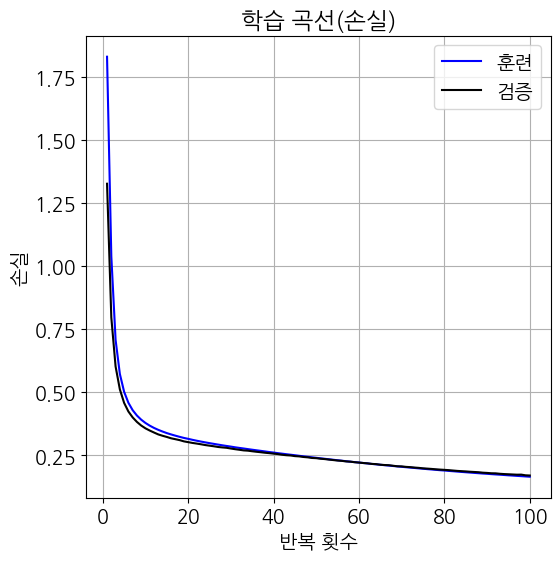

In [64]:
# 학습 곡선 출력(손실)

plt.plot(history[:,0], history[:,1], 'b', label='훈련')
plt.plot(history[:,0], history[:,3], 'k', label='검증')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')
plt.legend()
plt.show()

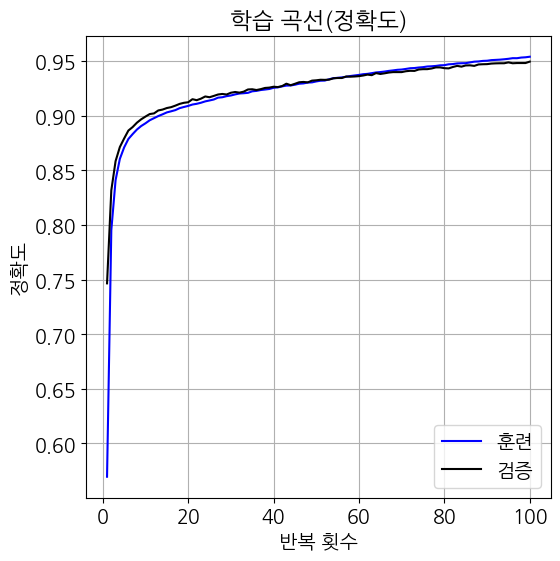

In [65]:
# 학습 곡선 출력(정확도)

plt.plot(history[:,0], history[:,2], 'b', label='훈련')
plt.plot(history[:,0], history[:,4], 'k', label='검증')
plt.xlabel('반복 횟수')
plt.ylabel('정확도')
plt.title('학습 곡선(정확도)')
plt.legend()
plt.show()

### 이미지 출력 확인

In [66]:
# 데이터로더에서 처음 한 세트 가져오기
for images, labels in test_loader:
    break

# 예측 결과 가져오기
inputs = images.to(device)
labels = labels.to(device)
outputs = net(inputs)
predicted = torch.max(outputs, 1)[1]

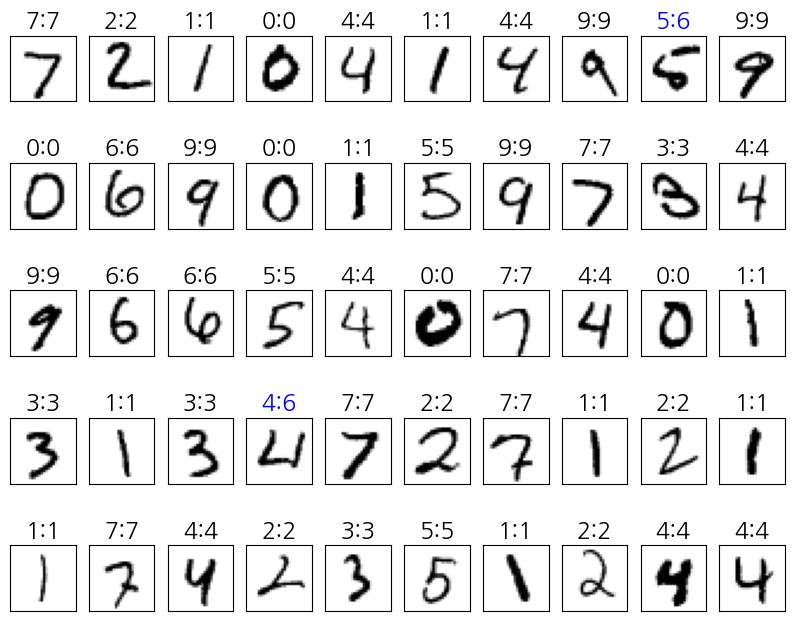

In [67]:
# 처음 50건의 이미지에 대해 "정답:예측"으로 출력

plt.figure(figsize=(10, 8))
for i in range(50):
  ax = plt.subplot(5, 10, i + 1)

  # 넘파이 배열로 변환
  image = images[i]
  label = labels[i]
  pred = predicted[i]
  if (pred == label):
    c = 'k'
  else:
    c = 'b'

  # 이미지의 범위를 [0, 1] 로 되돌림
  image2 = (image + 1)/ 2

  # 이미지 출력
  plt.imshow(image2.reshape(28, 28),cmap='gray_r')
  ax.set_title(f'{label}:{pred}', c=c)  # 실제 정답과 예측 비교
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()

## 8.14 은닉층 추가하기

In [68]:
# 모델 정의
# 784입력 10출력을 갖는 2개의 은닉층을 포함한 신경망

class Net2(nn.Module):
    def __init__(self, n_input, n_output, n_hidden):
        super().__init__()

        # 첫번째 은닉층 정의(은닉층 노드 수: n_hidden)
        self.l1 = nn.Linear(n_input, n_hidden)

        # 두번째 은닉층 정의(은닉층 노드 수: n_hidden)
        self.l2 = nn.Linear(n_hidden, n_hidden)

        # 출력층 정의
        self.l3 = nn.Linear(n_hidden, n_output)

        # ReLU 함수 정의
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x1 = self.l1(x)
        x2 = self.relu(x1)
        x3 = self.l2(x2)
        x4 = self.relu(x3)
        x5 = self.l3(x4)
        return x5

In [69]:
# 난수 고정
torch.manual_seed(123)
torch.cuda.manual_seed(123)

# 모델 초기화
net = Net2(n_input, n_output, n_hidden).to(device)

# 손실 함수： 교차 엔트로피 함수
criterion = nn.CrossEntropyLoss()

# 최적화 함수: 경사 하강법
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

In [70]:
# 모델 개요 표시 1

print(net)

Net2(
  (l1): Linear(in_features=784, out_features=128, bias=True)
  (l2): Linear(in_features=128, out_features=128, bias=True)
  (l3): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU(inplace=True)
)


In [71]:
# 모델 개요 표시 2

summary(net, (784,))

Layer (type:depth-idx)                   Output Shape              Param #
Net2                                     [10]                      --
├─Linear: 1-1                            [128]                     100,480
├─ReLU: 1-2                              [128]                     --
├─Linear: 1-3                            [128]                     16,512
├─ReLU: 1-4                              [128]                     --
├─Linear: 1-5                            [10]                      1,290
Total params: 118,282
Trainable params: 118,282
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 14.99
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.47
Estimated Total Size (MB): 0.48

In [72]:
# 데이터로더에서 처음 한 세트 가져오기
for images, labels in test_loader:
    break

# 예측 결과 가져오기
inputs = images.to(device)
labels = labels.to(device)

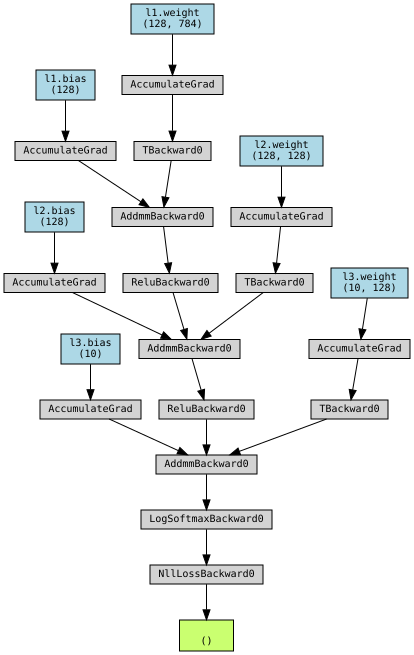

In [73]:
# 예측 계산
outputs = net(inputs)

# 손실 계산
loss = criterion(outputs, labels)

# 손실 계산 그래프 시각화
make_dot(loss, params=dict(net.named_parameters()))

### 경사 계산

In [74]:
# 경사 계산
loss.backward()

# 경사 계산 결과 일부
w = net.to('cpu').l1.weight.grad.numpy()
print(w)

# 각 요소의 절댓값 평균
print(np.abs(w).mean())

[[-0.0007 -0.0007 -0.0007 ... -0.0007 -0.0007 -0.0007]
 [-0.0001 -0.0001 -0.0001 ... -0.0001 -0.0001 -0.0001]
 [-0.0005 -0.0005 -0.0005 ... -0.0005 -0.0005 -0.0005]
 ...
 [ 0.0015  0.0015  0.0015 ...  0.0015  0.0015  0.0015]
 [ 0.0002  0.0002  0.0002 ...  0.0002  0.0002  0.0002]
 [ 0.0003  0.0003  0.0003 ...  0.0003  0.0003  0.0003]]
0.0008487979


### 반복 계산

In [75]:
# 난수 고정
torch.manual_seed(123)
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms = True


# 모델 초기화
net = Net2(n_input, n_output, n_hidden).to(device)

# 손실 함수： 교차 엔트로피 함수
criterion = nn.CrossEntropyLoss()

# 최적화 함수: 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수
num_epochs = 100

# 평가 결과 기록
history2 = np.zeros((0,5))

In [76]:
# 반복 계산 메인 루프

for epoch in range(num_epochs):
    train_acc = 0
    train_loss = 0
    val_acc = 0
    val_loss = 0
    n_train = 0
    n_test = 0

    # 훈련 페이즈
    for inputs, labels in tqdm(train_loader):
        n_train += len(labels)

        # GPU로 전송
        inputs = inputs.to(device)
        labels = labels.to(device)

        # 경사 초기화
        optimizer.zero_grad()

        # 예측 계산
        outputs = net(inputs)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 경사 계산
        loss.backward()

        # 파라미터 수정
        optimizer.step()

        # 예측 라벨 산출
        predicted = torch.max(outputs, 1)[1]

        # 손실과 정확도 계산
        train_loss += loss.item()
        train_acc += (predicted == labels).sum().item()

    # 예측 페이즈
    for inputs_test, labels_test in test_loader:
        n_test += len(labels_test)

        inputs_test = inputs_test.to(device)
        labels_test = labels_test.to(device)

        # 예측 계산
        outputs_test = net(inputs_test)

        # 손실 계산
        loss_test = criterion(outputs_test, labels_test)

        # 예측 라벨 산출
        predicted_test = torch.max(outputs_test, 1)[1]

        # 손실과 정확도 계산
        val_loss +=  loss_test.item()
        val_acc +=  (predicted_test == labels_test).sum().item()

    # 평가 결과 산출, 기록
    train_acc = train_acc / n_train
    val_acc = val_acc / n_test
    train_loss = train_loss * batch_size / n_train
    val_loss = val_loss * batch_size / n_test
    print (f'Epoch [{epoch+1}/{num_epochs}], loss: {train_loss:.5f} acc: {train_acc:.5f} val_loss: {val_loss:.5f}, val_acc: {val_acc:.5f}')
    item = np.array([epoch+1 , train_loss, train_acc, val_loss, val_acc])
    history2 = np.vstack((history2, item))

  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [1/100], loss: 2.20163 acc: 0.25380 val_loss: 2.04576, val_acc: 0.49800


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [2/100], loss: 1.75820 acc: 0.60443 val_loss: 1.39272, val_acc: 0.68680


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [3/100], loss: 1.11284 acc: 0.75645 val_loss: 0.86510, val_acc: 0.80810


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [4/100], loss: 0.75170 acc: 0.82300 val_loss: 0.63477, val_acc: 0.84380


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [5/100], loss: 0.59030 acc: 0.84983 val_loss: 0.52462, val_acc: 0.86370


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [6/100], loss: 0.50672 acc: 0.86653 val_loss: 0.46400, val_acc: 0.87440


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [7/100], loss: 0.45680 acc: 0.87540 val_loss: 0.42148, val_acc: 0.88560


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [8/100], loss: 0.42335 acc: 0.88195 val_loss: 0.39551, val_acc: 0.89020


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [9/100], loss: 0.39965 acc: 0.88768 val_loss: 0.37600, val_acc: 0.89350


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [10/100], loss: 0.38195 acc: 0.89183 val_loss: 0.35886, val_acc: 0.89880


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [11/100], loss: 0.36793 acc: 0.89477 val_loss: 0.34926, val_acc: 0.90350


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [12/100], loss: 0.35633 acc: 0.89803 val_loss: 0.33760, val_acc: 0.90400


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [13/100], loss: 0.34648 acc: 0.89965 val_loss: 0.32775, val_acc: 0.90580


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [14/100], loss: 0.33814 acc: 0.90202 val_loss: 0.32063, val_acc: 0.90760


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [15/100], loss: 0.33042 acc: 0.90457 val_loss: 0.31807, val_acc: 0.90760


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [16/100], loss: 0.32382 acc: 0.90603 val_loss: 0.31015, val_acc: 0.91130


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [17/100], loss: 0.31778 acc: 0.90760 val_loss: 0.30470, val_acc: 0.91140


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [18/100], loss: 0.31207 acc: 0.90910 val_loss: 0.30015, val_acc: 0.91420


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [19/100], loss: 0.30685 acc: 0.91078 val_loss: 0.29439, val_acc: 0.91420


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [20/100], loss: 0.30213 acc: 0.91208 val_loss: 0.29150, val_acc: 0.91500


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [21/100], loss: 0.29752 acc: 0.91375 val_loss: 0.28592, val_acc: 0.91640


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [22/100], loss: 0.29328 acc: 0.91498 val_loss: 0.28179, val_acc: 0.91750


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [23/100], loss: 0.28877 acc: 0.91608 val_loss: 0.27957, val_acc: 0.91850


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [24/100], loss: 0.28525 acc: 0.91685 val_loss: 0.27463, val_acc: 0.92080


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [25/100], loss: 0.28129 acc: 0.91833 val_loss: 0.27169, val_acc: 0.92160


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [26/100], loss: 0.27772 acc: 0.91927 val_loss: 0.26890, val_acc: 0.92210


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [27/100], loss: 0.27411 acc: 0.92007 val_loss: 0.26614, val_acc: 0.92380


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [28/100], loss: 0.27080 acc: 0.92125 val_loss: 0.26244, val_acc: 0.92470


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [29/100], loss: 0.26760 acc: 0.92232 val_loss: 0.26265, val_acc: 0.92320


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [30/100], loss: 0.26484 acc: 0.92292 val_loss: 0.25895, val_acc: 0.92430


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [31/100], loss: 0.26135 acc: 0.92375 val_loss: 0.25497, val_acc: 0.92660


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [32/100], loss: 0.25843 acc: 0.92477 val_loss: 0.25228, val_acc: 0.92730


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [33/100], loss: 0.25552 acc: 0.92570 val_loss: 0.25114, val_acc: 0.92570


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [34/100], loss: 0.25280 acc: 0.92637 val_loss: 0.24734, val_acc: 0.92770


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [35/100], loss: 0.24960 acc: 0.92760 val_loss: 0.24460, val_acc: 0.93060


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [36/100], loss: 0.24677 acc: 0.92835 val_loss: 0.24469, val_acc: 0.92770


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [37/100], loss: 0.24411 acc: 0.92962 val_loss: 0.24130, val_acc: 0.92830


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [38/100], loss: 0.24158 acc: 0.93008 val_loss: 0.23741, val_acc: 0.93190


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [39/100], loss: 0.23886 acc: 0.93110 val_loss: 0.23472, val_acc: 0.93290


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [40/100], loss: 0.23617 acc: 0.93165 val_loss: 0.23369, val_acc: 0.93230


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [41/100], loss: 0.23374 acc: 0.93222 val_loss: 0.22987, val_acc: 0.93330


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [42/100], loss: 0.23095 acc: 0.93275 val_loss: 0.22863, val_acc: 0.93270


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [43/100], loss: 0.22849 acc: 0.93407 val_loss: 0.22667, val_acc: 0.93570


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [44/100], loss: 0.22612 acc: 0.93477 val_loss: 0.22332, val_acc: 0.93500


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [45/100], loss: 0.22344 acc: 0.93500 val_loss: 0.22107, val_acc: 0.93450


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [46/100], loss: 0.22103 acc: 0.93582 val_loss: 0.21979, val_acc: 0.93630


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [47/100], loss: 0.21872 acc: 0.93680 val_loss: 0.21706, val_acc: 0.93650


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [48/100], loss: 0.21632 acc: 0.93757 val_loss: 0.21633, val_acc: 0.93740


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [49/100], loss: 0.21397 acc: 0.93832 val_loss: 0.21385, val_acc: 0.93840


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [50/100], loss: 0.21180 acc: 0.93890 val_loss: 0.21025, val_acc: 0.93730


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [51/100], loss: 0.20944 acc: 0.93947 val_loss: 0.20930, val_acc: 0.93890


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [52/100], loss: 0.20723 acc: 0.94013 val_loss: 0.20952, val_acc: 0.93590


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [53/100], loss: 0.20505 acc: 0.94080 val_loss: 0.20475, val_acc: 0.94080


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [54/100], loss: 0.20265 acc: 0.94133 val_loss: 0.20285, val_acc: 0.93920


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [55/100], loss: 0.20043 acc: 0.94240 val_loss: 0.20079, val_acc: 0.94180


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [56/100], loss: 0.19844 acc: 0.94278 val_loss: 0.19841, val_acc: 0.94190


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [57/100], loss: 0.19652 acc: 0.94387 val_loss: 0.19672, val_acc: 0.94180


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [58/100], loss: 0.19422 acc: 0.94392 val_loss: 0.19496, val_acc: 0.94240


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [59/100], loss: 0.19227 acc: 0.94440 val_loss: 0.19377, val_acc: 0.94300


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [60/100], loss: 0.19031 acc: 0.94528 val_loss: 0.19109, val_acc: 0.94320


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [61/100], loss: 0.18842 acc: 0.94557 val_loss: 0.18999, val_acc: 0.94430


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [62/100], loss: 0.18623 acc: 0.94682 val_loss: 0.18821, val_acc: 0.94430


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [63/100], loss: 0.18460 acc: 0.94673 val_loss: 0.18559, val_acc: 0.94500


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [64/100], loss: 0.18266 acc: 0.94707 val_loss: 0.18447, val_acc: 0.94500


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [65/100], loss: 0.18072 acc: 0.94807 val_loss: 0.18251, val_acc: 0.94560


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [66/100], loss: 0.17906 acc: 0.94835 val_loss: 0.18064, val_acc: 0.94540


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [67/100], loss: 0.17725 acc: 0.94930 val_loss: 0.17930, val_acc: 0.94620


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [68/100], loss: 0.17531 acc: 0.94973 val_loss: 0.17716, val_acc: 0.94670


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [69/100], loss: 0.17379 acc: 0.94982 val_loss: 0.17560, val_acc: 0.94860


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [70/100], loss: 0.17195 acc: 0.95057 val_loss: 0.17435, val_acc: 0.94790


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [71/100], loss: 0.17031 acc: 0.95115 val_loss: 0.17268, val_acc: 0.94830


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [72/100], loss: 0.16849 acc: 0.95137 val_loss: 0.17090, val_acc: 0.94890


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [73/100], loss: 0.16690 acc: 0.95195 val_loss: 0.17039, val_acc: 0.94960


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [74/100], loss: 0.16519 acc: 0.95257 val_loss: 0.16927, val_acc: 0.95040


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [75/100], loss: 0.16374 acc: 0.95277 val_loss: 0.16797, val_acc: 0.94950


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [76/100], loss: 0.16229 acc: 0.95353 val_loss: 0.16560, val_acc: 0.95140


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [77/100], loss: 0.16060 acc: 0.95375 val_loss: 0.16512, val_acc: 0.95150


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [78/100], loss: 0.15917 acc: 0.95432 val_loss: 0.16286, val_acc: 0.95140


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [79/100], loss: 0.15768 acc: 0.95463 val_loss: 0.16262, val_acc: 0.95160


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [80/100], loss: 0.15609 acc: 0.95530 val_loss: 0.16006, val_acc: 0.95310


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [81/100], loss: 0.15466 acc: 0.95563 val_loss: 0.15933, val_acc: 0.95280


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [82/100], loss: 0.15333 acc: 0.95590 val_loss: 0.15824, val_acc: 0.95270


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [83/100], loss: 0.15187 acc: 0.95628 val_loss: 0.15676, val_acc: 0.95300


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [84/100], loss: 0.15063 acc: 0.95693 val_loss: 0.15557, val_acc: 0.95400


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [85/100], loss: 0.14918 acc: 0.95718 val_loss: 0.15529, val_acc: 0.95400


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [86/100], loss: 0.14785 acc: 0.95778 val_loss: 0.15300, val_acc: 0.95410


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [87/100], loss: 0.14652 acc: 0.95782 val_loss: 0.15197, val_acc: 0.95440


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [88/100], loss: 0.14521 acc: 0.95833 val_loss: 0.15013, val_acc: 0.95480


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [89/100], loss: 0.14407 acc: 0.95883 val_loss: 0.14955, val_acc: 0.95500


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [90/100], loss: 0.14251 acc: 0.95927 val_loss: 0.14936, val_acc: 0.95510


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [91/100], loss: 0.14150 acc: 0.95972 val_loss: 0.14767, val_acc: 0.95540


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [92/100], loss: 0.14013 acc: 0.95967 val_loss: 0.14766, val_acc: 0.95580


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [93/100], loss: 0.13901 acc: 0.96018 val_loss: 0.14749, val_acc: 0.95610


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [94/100], loss: 0.13766 acc: 0.96070 val_loss: 0.14508, val_acc: 0.95630


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [95/100], loss: 0.13663 acc: 0.96098 val_loss: 0.14403, val_acc: 0.95620


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [96/100], loss: 0.13549 acc: 0.96135 val_loss: 0.14406, val_acc: 0.95680


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [97/100], loss: 0.13421 acc: 0.96170 val_loss: 0.14099, val_acc: 0.95690


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [98/100], loss: 0.13313 acc: 0.96215 val_loss: 0.14105, val_acc: 0.95710


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [99/100], loss: 0.13193 acc: 0.96240 val_loss: 0.13979, val_acc: 0.95710


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch [100/100], loss: 0.13093 acc: 0.96290 val_loss: 0.13874, val_acc: 0.95820


In [77]:
# 손실과 정확도 확인

print(f'초기상태 : 손실 : {history2[0,3]:.5f}  정확도 : {history2[0,4]:.5f}' )
print(f'최종상태 : 손실 : {history2[-1,3]:.5f}  정확도 : {history2[-1,4]:.5f}' )

초기상태 : 손실 : 2.04576  정확도 : 0.49800
최종상태 : 손실 : 0.13874  정확도 : 0.95820


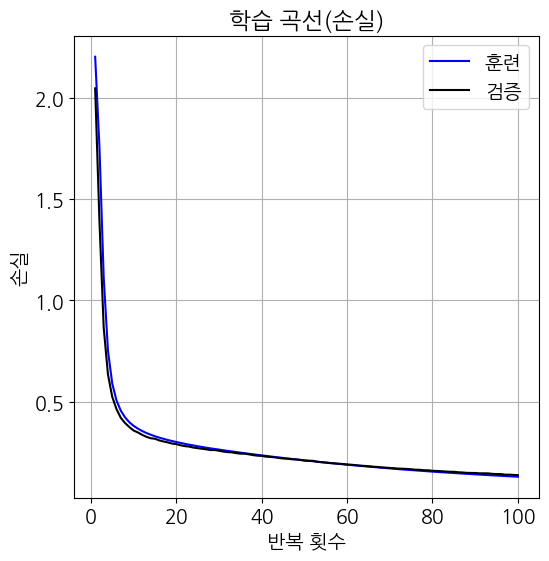

In [78]:
# 학습 곡선 출력(손실)
plt.plot(history2[:,0], history2[:,1], 'b', label='훈련')
plt.plot(history2[:,0], history2[:,3], 'k', label='검증')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')
plt.legend()
plt.show()

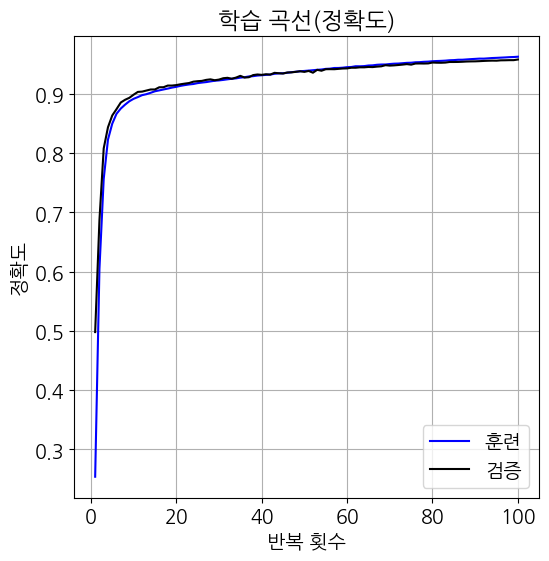

In [79]:
# 학습 곡선 출력(정확도)

plt.plot(history2[:,0], history2[:,2], 'b', label='훈련')
plt.plot(history2[:,0], history2[:,4], 'k', label='검증')
plt.xlabel('반복 횟수')
plt.ylabel('정확도')
plt.title('학습 곡선(정확도)')
plt.legend()
plt.show()

## 칼럼 경사 소실과 ReLU 함수

In [80]:
# 모델 정의 -　시그모이드 함수 버전
# 784입력 10출력을 갖는 2개의 은닉층을 포함한 신경망

class Net3(nn.Module):
    def __init__(self, n_input, n_output, n_hidden):
        super().__init__()

        # 첫번째 은닉층 정의(은닉층 노드 수: n_hidden)
        self.l1 = nn.Linear(n_input, n_hidden)

        # 두번째 은닉층 정의(은닉층 노드 수: n_hidden)
        self.l2 = nn.Linear(n_hidden, n_hidden)

        # 출력층 정의
        self.l3 = nn.Linear(n_hidden, n_output)

        # 시그모이드 함수 정의
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x1 = self.l1(x)
        x2 = self.sigmoid(x1)
        x3 = self.l2(x2)
        x4 = self.sigmoid(x3)
        x5 = self.l3(x4)
        return x5

In [81]:
# 난수 고정
torch.manual_seed(123)
torch.cuda.manual_seed(123)

# 모델 초기화
net = Net3(n_input, n_output, n_hidden).to(device)

# 손실 함수： 교차 엔트로피 함수
criterion = nn.CrossEntropyLoss()

# 최적화 함수: 경사 하강법
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

In [82]:
# 데이터로더에서 처음 한 세트 가져오기
for images, labels in test_loader:
    break

# 예측 결과 가져오기
inputs = images.to(device)
labels = labels.to(device)

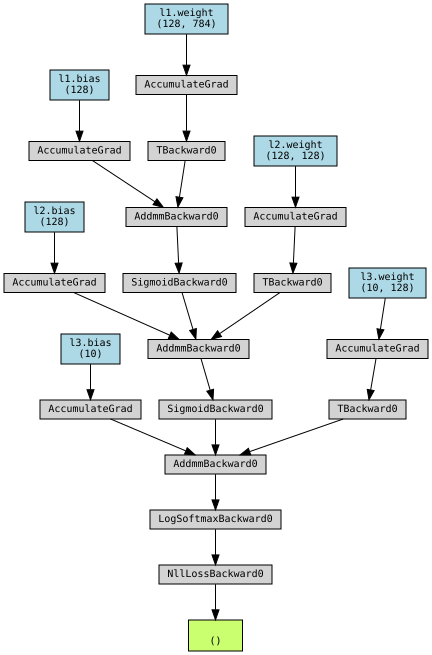

In [83]:
# 예측 계산
outputs = net(inputs)

# 손실 계산
loss = criterion(outputs, labels)

# 손실 계산 그래프 시각화
make_dot(loss, params=dict(net.named_parameters()))

In [84]:
# 경사 계산
loss.backward()

# 경사 계산 결과의 일부
w = net.to('cpu').l1.weight.grad.numpy()
print(w)

# 각 요소의 절댓값 평균
print(f'각 요소의 절댓값 평균: {np.abs(w).mean()}')

[[ 0.0001  0.0001  0.0001 ...  0.0001  0.0001  0.0001]
 [ 0.0001  0.0001  0.0001 ...  0.0001  0.0001  0.0001]
 [-0.0001 -0.0001 -0.0001 ... -0.0001 -0.0001 -0.0001]
 ...
 [-0.0001 -0.0001 -0.0001 ... -0.0001 -0.0001 -0.0001]
 [ 0.0002  0.0002  0.0002 ...  0.0002  0.0002  0.0002]
 [-0.0001 -0.0001 -0.0001 ... -0.0001 -0.0001 -0.0001]]
각 요소의 절댓값 평균: 0.00017514593491796404


## 칼럼 람다 표현식을 활용한 함수 정의

In [85]:
# 일반적인 함수의 정의

def f(x):
    return (2 * x**2 + 2)

In [86]:
x = np.arange(-2, 2.1, 0.25)
y = f(x)
print(y)

[10.     8.125  6.5    5.125  4.     3.125  2.5    2.125  2.     2.125
  2.5    3.125  4.     5.125  6.5    8.125 10.   ]


In [87]:
# 람다 표현식으로 함수 정의

g = lambda x: 2 * x**2 + 2

In [88]:
y = g(x)
print(y)

[10.     8.125  6.5    5.125  4.     3.125  2.5    2.125  2.     2.125
  2.5    3.125  4.     5.125  6.5    8.125 10.   ]


## 칼럼 배치 사이즈와 정확도의 관계

### fit 함수의 정의

In [89]:
# 학습용 함수
def fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history):
    base_epochs = len(history)
    for epoch in range(base_epochs, num_epochs+base_epochs):
        train_loss = 0
        train_acc = 0
        val_loss = 0
        val_acc = 0

        # 훈련 페이즈
        count = 0

        for inputs, labels in tqdm(train_loader):
            count += len(labels)
            inputs = inputs.to(device)
            labels = labels.to(device)

            # 경사 초기화
            optimizer.zero_grad()

            # 예측 계산
            outputs = net(inputs)

            # 손실 계산
            loss = criterion(outputs, labels)
            train_loss += loss.item()

            # 경사 계산
            loss.backward()

            # 파라미터 수정
            optimizer.step()

            # 예측 라벨 산출
            predicted = torch.max(outputs, 1)[1]

            # 정답 건수 산출
            train_acc += (predicted == labels).sum().item()

            # 훈련 데이터에 대해 손실과 정확도 계산
            avg_train_loss = train_loss / count
            avg_train_acc = train_acc / count

        # 예측 페이즈
        count = 0

        for inputs, labels in test_loader:
            count += len(labels)

            inputs = inputs.to(device)
            labels = labels.to(device)

            # 예측 계산
            outputs = net(inputs)

            # 손실 계산
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # 예측 라벨 산출
            predicted = torch.max(outputs, 1)[1]

            # 정답 건수 산출
            val_acc += (predicted == labels).sum().item()

            # 검증 데이터에 대해 손실과 정확도 계산
            avg_val_loss = val_loss / count
            avg_val_acc = val_acc / count

        print (f'Epoch [{(epoch+1)}/{num_epochs+base_epochs}], loss: {avg_train_loss:.5f} acc: {avg_train_acc:.5f} val_loss: {avg_val_loss:.5f}, val_acc: {avg_val_acc:.5f}')
        item = np.array([epoch+1, avg_train_loss, avg_train_acc, avg_val_loss, avg_val_acc])
        history = np.vstack((history, item))
    return history

In [90]:
# 파이토치 난수 고정

def torch_seed(seed=123):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

In [91]:
# 미니 배치 사이즈 지정
batch_size_train = 500

# 훈련용 데이터로더
# 훈련용이므로 셔플을 적용함
train_loader = DataLoader(
    train_set, batch_size = batch_size_train,
    shuffle = True)

# 난수 고정
torch_seed()

# 학습률
lr = 0.01

# 모델 초기화
net = Net(n_input, n_output, n_hidden).to(device)

# 최적화 함수: 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 손실 함수： 교차 엔트로피 함수
criterion = nn.CrossEntropyLoss()

# 반복 횟수
num_epochs = 100

# 평가 결과 기록
history6 = np.zeros((0,5))

In [ ]:
history6 = fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history6)

### batch_size=200

In [ ]:
# 미니 배치 사이즈 지정
batch_size_train = 200

# 훈련용 데이터로더
# 훈련용이므로 셔플을 적용함
train_loader = DataLoader(
    train_set, batch_size = batch_size_train,
    shuffle = True)

# 난수 고정
torch_seed()

# 학습률
lr = 0.01

# 모델 초기화
net = Net(n_input, n_output, n_hidden).to(device)

# 최적화 함수: 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 손실 함수： 교차 엔트로피 함수
criterion = nn.CrossEntropyLoss()

# 반복 횟수
num_epochs = 100

# 평가 결과 기록
history3 = np.zeros((0,5))

In [ ]:
history3 = fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history3)

### batch_size=100

In [ ]:
# 미니 배치 사이즈 지정
batch_size_train = 100

# 훈련용 데이터로더
# 훈련용이므로 셔플을 적용함
train_loader = DataLoader(
    train_set, batch_size = batch_size_train,
    shuffle = True)

# 난수 고정
torch_seed()

# 학습률
lr = 0.01

# 모델 초기화
net = Net(n_input, n_output, n_hidden).to(device)

# 최적화 함수: 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 손실 함수： 교차 엔트로피 함수
criterion = nn.CrossEntropyLoss()

# 반복 횟수
num_epochs = 100

# 평가 결과 기록
history4 = np.zeros((0,5))

In [ ]:
history4 = fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history4)

### batch_size=50

In [ ]:
# 미니 배치 사이즈 지정
batch_size_train = 50

# 훈련용 데이터로더
# 훈련용이므로 셔플을 적용함
train_loader = DataLoader(
    train_set, batch_size = batch_size_train,
    shuffle = True)

# 난수 고정
torch_seed()

# 학습률
lr = 0.01

# 모델 초기화
net = Net(n_input, n_output, n_hidden).to(device)

# 최적화 함수: 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 손실 함수： 교차 엔트로피 함수
criterion = nn.CrossEntropyLoss()

# 반복 횟수
num_epochs = 100

# 평가 결과 기록
history5 = np.zeros((0,5))

In [ ]:
history5 = fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history5)

### 학습 곡선 비교

In [ ]:
# 학습 곡선 출력(정확도)

plt.plot(history[:,0], history[:,4], label='batch_size=500', c='k', linestyle='-.')
plt.plot(history3[:,0], history3[:,4], label='batch_size=200', c='b', linestyle='-.')
plt.plot(history4[:,0], history4[:,4], label='batch_size=100', c='k')
plt.plot(history5[:,0], history5[:,4], label='batch_size=50', c='b')
plt.xlabel('반복 횟수')
plt.ylabel('정확도')
plt.title('학습 곡선(정확도)')
plt.legend()
plt.show()

In [ ]:
# eos